<a href="https://colab.research.google.com/github/zeynepuygrr/softito_hw/blob/main/21_09_2026odev2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spam E-posta Sınıflandırması
**Veri seti:** UCI Machine Learning Repository — Spambase (id=94, Hopkins vd. 1999)

**Hedef:** Bir e-postanın içerdiği kelime/karakter sıklıklarından **spam (1)** mi **spam değil (0)** mi olduğunu tahmin etmek.

In [ ]:
!pip install ucimlrepo -q

In [ ]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print(f"python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
seaborn: 0.13.2
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1


## 1. Veri setini UCI'dan yükleme

In [ ]:
from ucimlrepo import fetch_ucirepo

spam = fetch_ucirepo(id=94)

X_clf = spam.data.features
y_clf = spam.data.targets.iloc[:, 0]   # DataFrame -> Series
y_clf.name = "hedef"

print(X_clf.shape, y_clf.shape)
X_clf.head(2)

(4601, 57) (4601,)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.0,0.00,...,0.0,0.0,0.000,0.0,0.778,0.00,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.0,0.94,...,0.0,0.0,0.132,0.0,0.372,0.18,0.048,5.114,101,1028


In [ ]:
X_clf.isna().sum().sum()   # toplam eksik değer sayısı

np.int64(0)

## 2. Sınıf dağılımı ve özet istatistikler

In [ ]:
print("Sınıf dağılımı (0 = spam değil, 1 = spam):")
print(y_clf.value_counts().rename({0: "spam değil", 1: "spam"}))
print()
print(y_clf.value_counts(normalize=True).round(3))

X_clf.iloc[:, :6].describe().T.round(2)

Sınıf dağılımı (0 = spam değil, 1 = spam):
hedef
spam değil    2788
spam          1813
Name: count, dtype: int64

hedef
0    0.606
1    0.394
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.10,0.31,0.0,0.0,0.0,0.00,4.54
word_freq_address,4601.0,0.21,1.29,0.0,0.0,0.0,0.00,14.28
word_freq_all,4601.0,0.28,0.50,0.0,0.0,0.0,0.42,5.10
word_freq_3d,4601.0,0.07,1.40,0.0,0.0,0.0,0.00,42.81
word_freq_our,4601.0,0.31,0.67,0.0,0.0,0.0,0.38,10.00
word_freq_over,4601.0,0.10,0.27,0.0,0.0,0.0,0.00,5.88


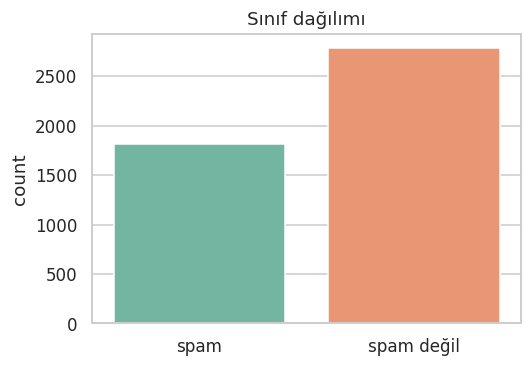

In [ ]:
plt.figure(figsize=(5, 3.5))
sns.countplot(x=y_clf.map({0: "spam değil", 1: "spam"}), palette="Set2")
plt.title("Sınıf dağılımı")
plt.xlabel("")
plt.tight_layout()
plt.show()

## 3. Eğitim / test ayırma
`stratify=y_clf` ile iki kümede de spam oranı aynı kalır.

In [ ]:
from sklearn.model_selection import train_test_split

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)
print(f"Eğitim: {Xc_train.shape[0]} | Test: {Xc_test.shape[0]}")

Eğitim: 3680 | Test: 921


## 4. Modelleri eğitme ve karşılaştırma
Logistic Regression ve KNN, özelliklerin ölçeğine duyarlı olduğu için `StandardScaler` ile pipeline içinde kullanılıyor. Karar ağacı ve rastgele orman ölçeklendirme gerektirmez.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "Karar ağacı": DecisionTreeClassifier(random_state=SEED),
    "Rastgele orman": RandomForestClassifier(random_state=SEED),
}

satirlar = []
for ad, m in siniflandiricilar.items():
    m.fit(Xc_train, yc_train)
    satirlar.append({
        "Model": ad,
        "Eğitim": accuracy_score(yc_train, m.predict(Xc_train)),
        "Test": accuracy_score(yc_test, m.predict(Xc_test)),
    })

pd.DataFrame(satirlar).set_index("Model").round(3)

,Eğitim,Test
Model,,
Baseline,0.606,0.606
Logistic,0.931,0.929
KNN,0.935,0.908
Karar ağacı,1.000,0.911
Rastgele orman,1.000,0.945


## 5. Karışıklık matrisi ve ROC eğrisi

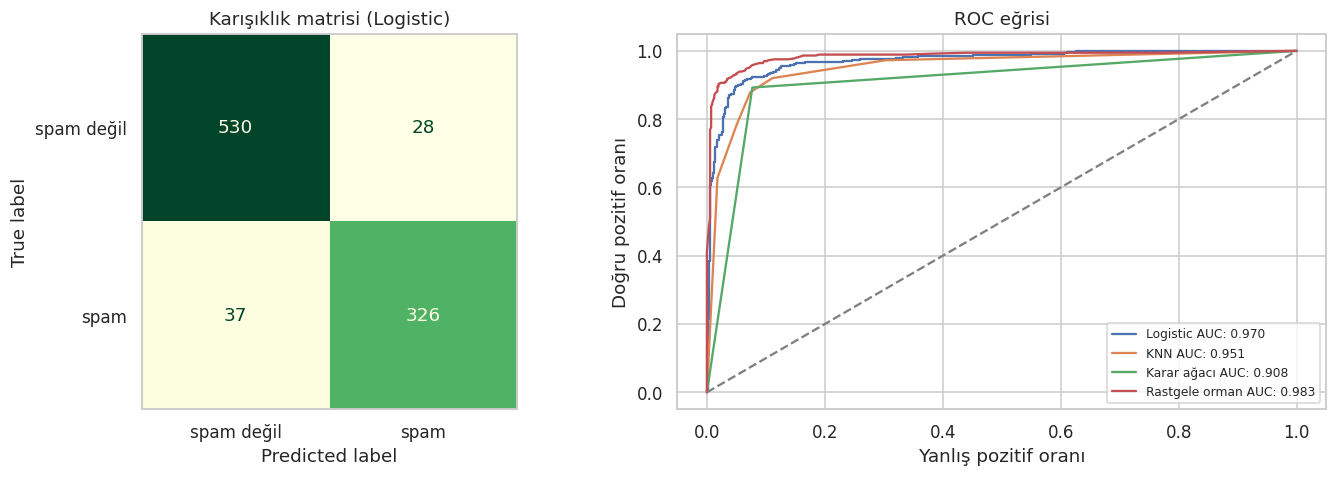

              precision    recall  f1-score   support

  spam değil       0.93      0.95      0.94       558
        spam       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



In [ ]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, roc_auc_score)

model = siniflandiricilar["Logistic"]
tahmin = model.predict(Xc_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ConfusionMatrixDisplay.from_predictions(
    yc_test, tahmin, display_labels=["spam değil", "spam"],
    cmap="YlGn", ax=axes[0], colorbar=False
)
axes[0].set_title("Karışıklık matrisi (Logistic)")
axes[0].grid(False)

for ad in ["Logistic", "KNN", "Karar ağacı", "Rastgele orman"]:
    p = siniflandiricilar[ad].predict_proba(Xc_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, p)
    axes[1].plot(fpr, tpr, label=f"{ad} AUC: {roc_auc_score(yc_test, p):.3f}")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("Yanlış pozitif oranı")
axes[1].set_ylabel("Doğru pozitif oranı")
axes[1].set_title("ROC eğrisi")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(classification_report(yc_test, tahmin, target_names=["spam değil", "spam"]))

## 6. Çapraz doğrulama (5 katlı)
Tek bir train/test ayrımı şansa bağlı olabilir. `StratifiedKFold` veriyi 5 farklı şekilde bölüp sınıf oranını korur, ortalama skor daha güvenilirdir.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

satirlar = []
for ad, m in siniflandiricilar.items():
    skorlar = cross_val_score(m, Xc_train, yc_train, cv=cv, scoring="accuracy")
    satirlar.append({"Model": ad, "Ortalama skor": skorlar.mean(), "Standart sapma": skorlar.std()})

cv_sonuc = pd.DataFrame(satirlar).set_index("Model").sort_values("Ortalama skor", ascending=False).round(3)
display(cv_sonuc)

,Ortalama skor,Standart sapma
Model,,
Rastgele orman,0.952,0.005
Logistic,0.923,0.011
Karar ağacı,0.914,0.010
KNN,0.907,0.004
Baseline,0.606,0.000


## 7. Hiperparametre ayarı (GridSearchCV)
CV'de en iyi çıkan modellerden biri olan Rastgele Orman için en iyi ayarları arıyoruz.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
}

opt = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid,
                   cv=cv, scoring="accuracy", n_jobs=-1)
opt.fit(Xc_train, yc_train)

print("En iyi parametreler:", opt.best_params_)
print(f"En iyi CV skoru: {opt.best_score_:.3f}")

En iyi parametreler: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
En iyi CV skoru: 0.953


## 8. Son kontrol: test kümesinde en iyi model

In [ ]:
en_iyi = opt.best_estimator_
tahmin_son = en_iyi.predict(Xc_test)
print(f"Test accuracy: {accuracy_score(yc_test, tahmin_son):.3f}")
print(f"Test AUC: {roc_auc_score(yc_test, en_iyi.predict_proba(Xc_test)[:, 1]):.3f}")
print(classification_report(yc_test, tahmin_son, target_names=["spam değil", "spam"]))

Test accuracy: 0.946
Test AUC: 0.983
              precision    recall  f1-score   support

  spam değil       0.94      0.97      0.96       558
        spam       0.95      0.91      0.93       363

    accuracy                           0.95       921
   macro avg       0.95      0.94      0.94       921
weighted avg       0.95      0.95      0.95       921

